In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../../datasets/Facturacionagua.csv", sep=";")

In [5]:
df.head

<bound method NDFrame.head of       CodArea NomArea  Calle  Portal Bloque Piso Mano     NIA  Ref unica  \
0        3003   AMA-3   1770       1    NaN   BJ  NaN  422521    1950546   
1        3003   AMA-3   1770       1    NaN  NaN  NaN  288966    1218508   
2        3003   AMA-3   1770       1    NaN    1  DCH   43572    1891949   
3        3003   AMA-3   1770       1    NaN   BJ  NaN  422521    1950535   
4        3003   AMA-3   1970      19    NaN    1  DCH  379819    1557743   
...       ...     ...    ...     ...    ...  ...  ...     ...        ...   
6901    13005   ORI-5   8750      14    NaN    3    B  280213    1230175   
6902    13005   ORI-5   8750      14    NaN    3    A  326155    1230153   
6903    13005   ORI-5   8750      14    NaN    2    B  162818    1926483   
6904    13005   ORI-5   8750      14    NaN    2    A  172773    1230131   
6905    13005   ORI-5   8750      25    NaN    2    B  388660    1868527   

       FechaUlti  LectUlti TipoLectUlti    FechaAnt  Lect

In [6]:
df.info

<bound method DataFrame.info of       CodArea NomArea  Calle  Portal Bloque Piso Mano     NIA  Ref unica  \
0        3003   AMA-3   1770       1    NaN   BJ  NaN  422521    1950546   
1        3003   AMA-3   1770       1    NaN  NaN  NaN  288966    1218508   
2        3003   AMA-3   1770       1    NaN    1  DCH   43572    1891949   
3        3003   AMA-3   1770       1    NaN   BJ  NaN  422521    1950535   
4        3003   AMA-3   1970      19    NaN    1  DCH  379819    1557743   
...       ...     ...    ...     ...    ...  ...  ...     ...        ...   
6901    13005   ORI-5   8750      14    NaN    3    B  280213    1230175   
6902    13005   ORI-5   8750      14    NaN    3    A  326155    1230153   
6903    13005   ORI-5   8750      14    NaN    2    B  162818    1926483   
6904    13005   ORI-5   8750      14    NaN    2    A  172773    1230131   
6905    13005   ORI-5   8750      25    NaN    2    B  388660    1868527   

       FechaUlti  LectUlti TipoLectUlti    FechaAnt  Le

In [7]:
df.shape

(6906, 17)

In [8]:
df.columns

Index(['CodArea', 'NomArea', 'Calle', 'Portal', 'Bloque', 'Piso', 'Mano',
       'NIA', 'Ref unica', 'FechaUlti', 'LectUlti', 'TipoLectUlti', 'FechaAnt',
       'LectAnt', 'TipoLectAnt', 'Tarifa', 'F Alta'],
      dtype='str')

In [9]:
df['FechaUlti'] = pd.to_datetime(df['FechaUlti'])
df['FechaAnt'] = pd.to_datetime(df['FechaAnt'])
df['F Alta'] = pd.to_datetime(df['F Alta'])

In [10]:
df['Consumo'] = df['LectUlti'] - df['LectAnt']

In [11]:
df[['LectUlti', 'LectAnt', 'Consumo']].head()

,LectUlti,LectAnt,Consumo
0,2021,1996,25
1,31905,31781,124
2,94,89,5
3,1455,1439,16
4,2050,2002,48


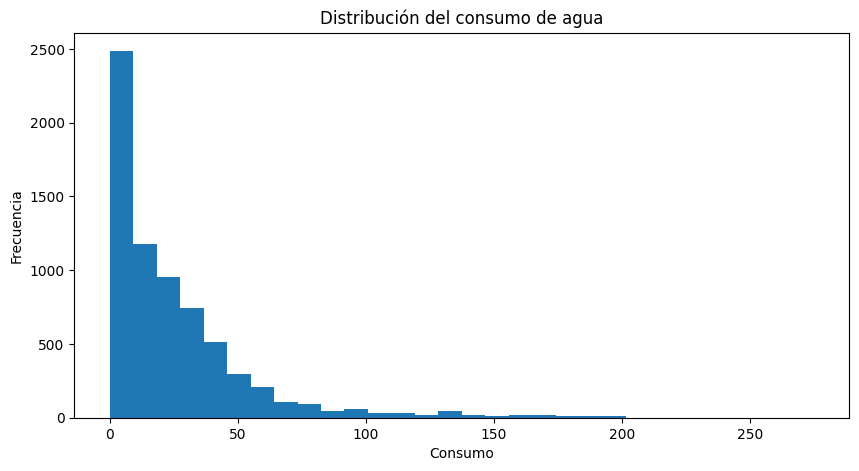

In [12]:
plt.figure(figsize=(10,5))

plt.hist(df['Consumo'], bins=30)

plt.title("Distribución del consumo de agua")
plt.xlabel("Consumo")
plt.ylabel("Frecuencia")

plt.show()

## 📊 Interpretación de la distribución del consumo de agua

La mayoría de los consumos de agua se concentran en valores bajos, especialmente entre 0 y 50 unidades de consumo.

La distribución presenta una clara asimetría positiva (sesgo a la derecha), ya que existen pocos usuarios con consumos muy altos, mientras que la mayoría tiene consumos moderados o bajos.

### 🔍 Observaciones principales

- La mayor frecuencia se encuentra en consumos pequeños.
- Existen valores extremos que superan los 100 e incluso 200.
- La distribución no es normal debido a la larga cola hacia la derecha.
- Podrían existir clientes con consumos anómalos o usos intensivos de agua.

### 📈 Conclusión

El patrón observado indica que el consumo de agua no es uniforme entre los clientes. La mayoría presenta consumos reducidos, mientras que un pequeño grupo concentra consumos significativamente más altos.

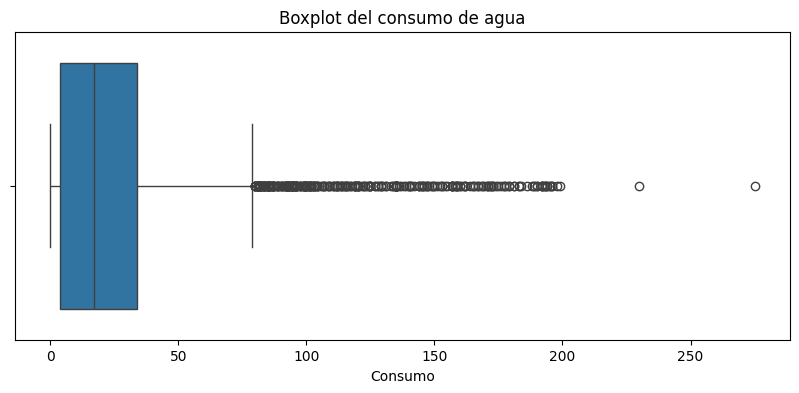

In [13]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df['Consumo'])

plt.title("Boxplot del consumo de agua")

plt.show()

## 📦 Interpretación del boxplot del consumo de agua

El boxplot muestra que la mayoría de los consumos se concentran en valores relativamente bajos y moderados.

### 🔍 Observaciones principales

- La mediana del consumo se sitúa en valores bajos.
- La mayor parte de los datos se concentra en un rango reducido.
- Existen valores atípicos (outliers) claramente alejados del resto.
- La distribución presenta asimetría positiva debido a consumos extremos elevados.

### 📈 Conclusión

La mayoría de usuarios mantiene un consumo estable y moderado, mientras que unos pocos presentan consumos excepcionalmente altos, lo que podría indicar usos intensivos o comportamientos anómalos.

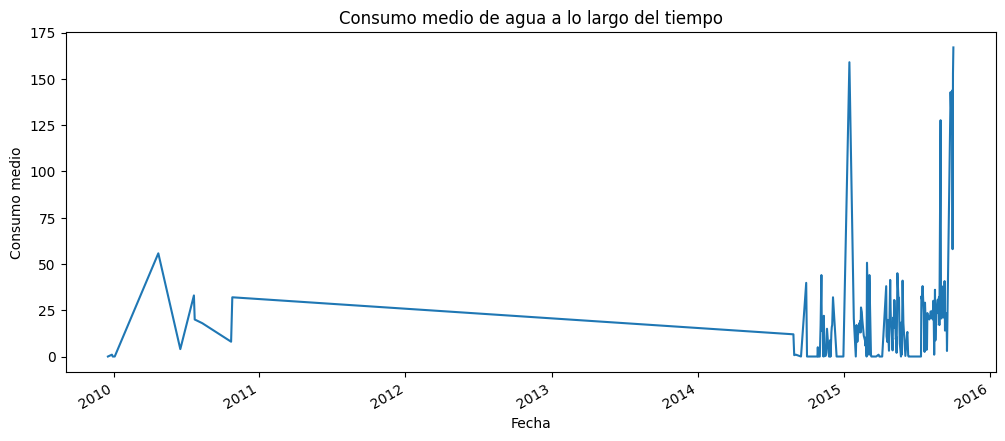

In [14]:
consumo_fecha = df.groupby('FechaUlti')['Consumo'].mean()

plt.figure(figsize=(12,5))

consumo_fecha.plot()

plt.title("Consumo medio de agua a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("Consumo medio")

plt.show()

## 📈 Interpretación de la evolución temporal del consumo de agua

La gráfica muestra cómo varía el consumo medio de agua a lo largo del tiempo.

### 🔍 Observaciones principales

- El consumo presenta una alta variabilidad entre diferentes fechas.
- Existen picos de consumo especialmente elevados en algunos periodos.
- A partir de 2015 se observan oscilaciones más intensas.
- Algunos valores cercanos a cero podrían indicar ausencia parcial de datos o consumos muy reducidos.

### 📊 Conclusión

El comportamiento temporal del consumo no es estable y muestra fluctuaciones importantes. La presencia de picos elevados sugiere posibles consumos excepcionales o valores atípicos que podrían requerir un análisis más detallado.

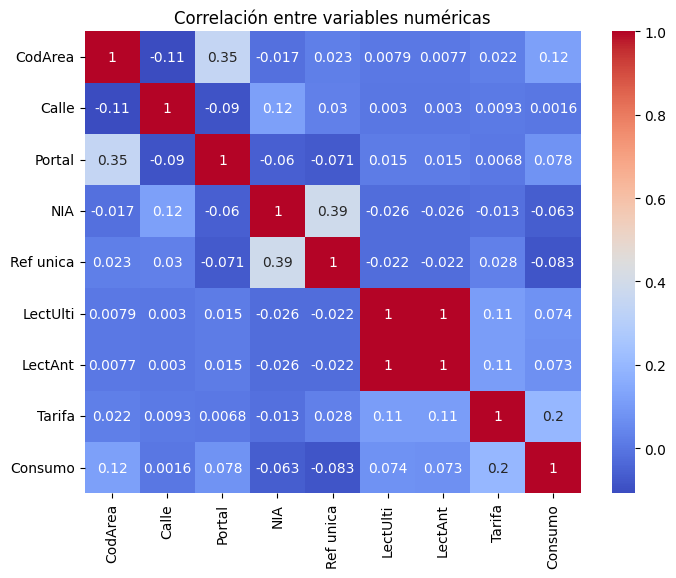

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlación entre variables numéricas")

plt.show()

## 🔥 Interpretación del mapa de correlaciones

El heatmap permite analizar la relación lineal entre las variables numéricas del dataset.

### 🔍 Observaciones principales

- `LectUlti` y `LectAnt` presentan una correlación prácticamente perfecta.
- Esto indica que las lecturas actuales y anteriores evolucionan de forma muy similar.
- La mayoría de variables muestran correlaciones débiles o cercanas a cero.
- `NIA` y `Ref unica` presentan una correlación positiva moderada.

### 📊 Conclusión

Las variables relacionadas con las lecturas del contador son las que presentan relaciones más fuertes dentro del dataset. En general, el resto de variables administrativas no muestran dependencias lineales importantes.

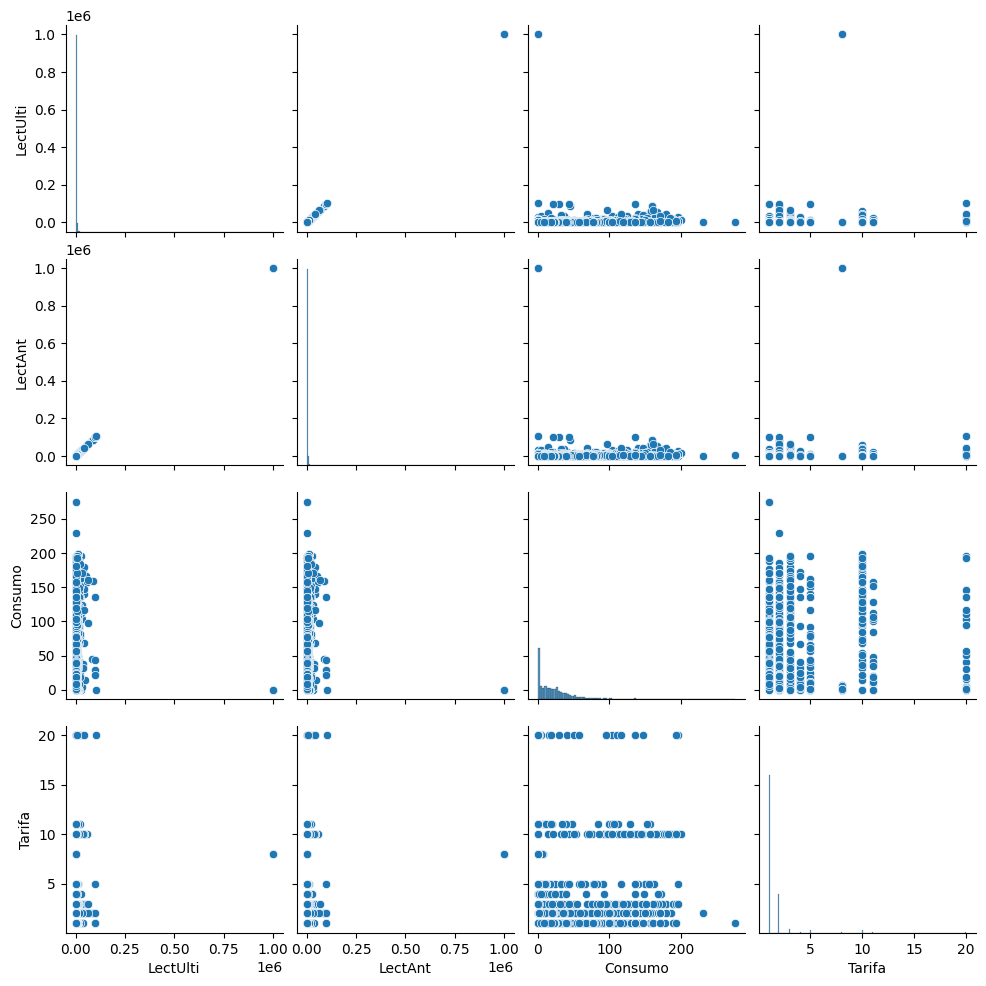

In [16]:
sns.pairplot(
    df[['LectUlti', 'LectAnt', 'Consumo', 'Tarifa']]
)

plt.show()

## 🎨 Interpretación del pairplot

El pairplot permite comparar visualmente las relaciones entre múltiples variables numéricas del dataset.

### 🔍 Observaciones principales

- La mayoría de las lecturas se concentran en valores bajos.
- Existen valores extremos muy alejados del resto de observaciones.
- La distribución del consumo presenta una fuerte asimetría positiva.
- La variable `Tarifa` muestra valores discretos que representan categorías tarifarias.
- Se observan algunos posibles outliers en las lecturas y consumos.

### 📊 Conclusión

El análisis visual muestra una distribución desigual de los consumos y lecturas, con presencia de valores atípicos significativos. Además, las tarifas parecen estar organizadas en grupos claramente diferenciados.

In [17]:
df[df['Consumo'] > 150][['Consumo', 'Tarifa', 'FechaUlti']].head(10)

,Consumo,Tarifa,FechaUlti
30,275,1,2015-08-06
114,175,10,2015-09-25
325,192,10,2015-08-05
420,181,10,2015-08-05
735,179,3,2015-09-25
736,169,2,2015-08-04
762,190,3,2015-04-27
773,230,2,2015-04-29
891,172,4,2015-08-06
910,153,2,2015-07-23


## 🚨 Detección de consumos extremos

Se han filtrado los registros con consumos superiores a 150 unidades para identificar posibles valores atípicos.

### 🔍 Observaciones principales

- Existen clientes con consumos significativamente superiores al promedio.
- Muchos de los consumos extremos se concentran en el año 2015.
- Los valores elevados aparecen asociados a diferentes tipos de tarifa.
- Algunos registros superan ampliamente el rango habitual observado anteriormente.

### 📊 Conclusión

El dataset contiene varios consumos anómalos o excepcionales que podrían corresponder a usos intensivos, fugas, errores de medición o perfiles de consumo especiales.

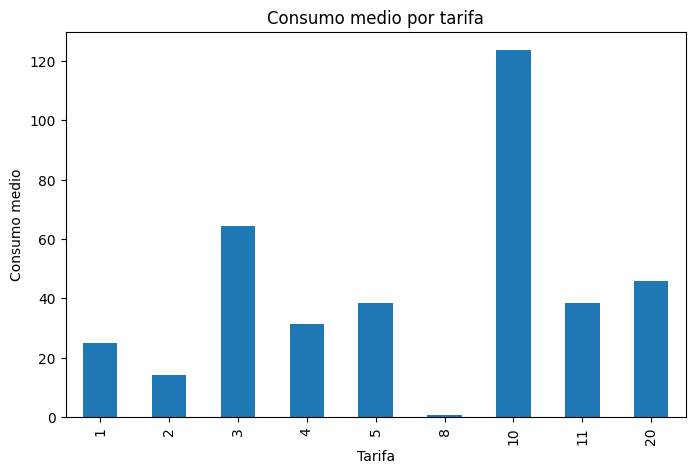

In [18]:
consumo_tarifa = df.groupby('Tarifa')['Consumo'].mean()

plt.figure(figsize=(8,5))

consumo_tarifa.plot(kind='bar')

plt.title("Consumo medio por tarifa")
plt.xlabel("Tarifa")
plt.ylabel("Consumo medio")

plt.show()

## 📊 Interpretación del consumo medio por tarifa

La gráfica muestra el consumo medio de agua para cada categoría tarifaria.

### 🔍 Observaciones principales

- La tarifa 10 presenta el consumo medio más elevado.
- Las tarifas 3 y 20 también muestran consumos relativamente altos.
- Las tarifas 1 y 2 presentan consumos más moderados.
- La tarifa 8 tiene un consumo medio muy reducido.

### 📈 Conclusión

Los resultados sugieren que las tarifas representan distintos perfiles de consumo. Algunas categorías parecen asociadas a clientes con consumos intensivos, mientras que otras corresponden a consumos más bajos o domésticos.